# CleanWatt — Model Walkthrough

This notebook walks through every modeling decision end-to-end:

1. **Feature matrix** — load the engineered features and understand what each group contributes
2. **Target series** — visualize carbon intensity and its structure (seasonal, hourly, distribution)
3. **Feature correlations** — see which features track the target most closely
4. **Single-horizon model (h=1)** — train one LightGBM, inspect feature importances
5. **Walk-forward backtest** — expanding-window evaluation across all 24 horizons
6. **Evaluation** — MAE per horizon, skill score vs the naïve "same hour yesterday" baseline

In [1]:
# IMPORTS

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

from cleanwatt.features import build_feature_matrix

# matplotlib config
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Feature Matrix

`build_feature_matrix` chains these steps:

- **Calendar** — hour, day-of-week, month, is_weekend (converted to Ontario local time so hour 9 means 9am in Toronto, not UTC)
- **Lags** — `lag_24h` and `lag_48h` of carbon intensity (same hour yesterday / two days ago)
- **Fuel fractions** — each fuel's MW share of total generation. Strong signal at near horizons.
- **Weather** — temperature and wind speed from Open-Meteo's historical API (free, no key)
- **Wind forecast leads** — `wind_speed_lead_6h / 12h / 24h`: observed future wind speed shifted forward. These are oracle values at training time; at inference time they'd come from Open-Meteo's forecast API. Gives the far-horizon models a wind signal they didn't have before.
- **Ontario demand** — hourly Ontario demand (MW) from IESO via gridstatus. Proxy at training time; at inference time substitute the official IESO demand forecast.

First run fetches ~3.5 years of weather + demand and saves to cache. Subsequent runs load from cache (~2 seconds).

In [2]:
import os
import pyarrow.parquet as pq

CARBON_PATH = '../data/processed/carbon_intensity.parquet'
CACHE_PATH  = '../data/processed/feature_matrix.parquet'

# Delete stale cache if it's missing the new columns (wind leads + demand_mw)
NEW_COLS = {'wind_speed_lead_6h', 'wind_speed_lead_12h', 'wind_speed_lead_24h', 'demand_mw'}
if os.path.exists(CACHE_PATH):
    cached_cols = set(pq.read_schema(CACHE_PATH).names)  # schema only — no data read
    if not NEW_COLS.issubset(cached_cols):
        os.remove(CACHE_PATH)
        print('Deleted stale cache (missing new features) — rebuilding...')

if os.path.exists(CACHE_PATH):
    df = pd.read_parquet(CACHE_PATH)
    print(f'Loaded from cache ({len(df):,} rows)')
else:
    print('Building feature matrix — fetching weather + demand (~2 min)...')
    df = build_feature_matrix(CARBON_PATH, drop_na=True)
    df.to_parquet(CACHE_PATH)
    print(f'Saved to {CACHE_PATH}')

print(f'\nDate range : {df.index.min().date()} -> {df.index.max().date()}')
print(f'Shape      : {df.shape}')
print(f'Columns    : {sorted(df.columns.tolist())}')

Deleted stale cache (missing new features) — rebuilding...
Building feature matrix — fetching weather + demand (~2 min)...
Saved to ../data/processed/feature_matrix.parquet

Date range : 2023-01-03 -> 2026-06-13
Shape      : (30168, 26)
Columns    : ['biofuel', 'carbon_intensity', 'carbon_intensity_lag_24h', 'carbon_intensity_lag_48h', 'day_of_week', 'demand_mw', 'gas', 'hour_of_day', 'hydro', 'is_weekend', 'month', 'nuclear', 'other', 'pct_biofuel', 'pct_gas', 'pct_hydro', 'pct_nuclear', 'pct_solar', 'pct_wind', 'solar', 'temperature_2m', 'wind', 'wind_speed_10m', 'wind_speed_lead_12h', 'wind_speed_lead_24h', 'wind_speed_lead_6h']


In [3]:
FEATURE_COLS = [
    'hour_of_day', 'day_of_week', 'month', 'is_weekend',
    'carbon_intensity_lag_24h', 'carbon_intensity_lag_48h',
    'pct_wind', 'pct_gas', 'pct_hydro', 'pct_nuclear', 'pct_solar', 'pct_biofuel',
    'temperature_2m', 'wind_speed_10m',
    'wind_speed_lead_6h', 'wind_speed_lead_12h', 'wind_speed_lead_24h',
    'demand_mw',
]
TARGET = 'carbon_intensity'

# Null check — NaN features cause silent errors in LightGBM
null_counts = df[FEATURE_COLS + [TARGET]].isnull().sum()
has_nulls = null_counts[null_counts > 0]
if has_nulls.empty:
    print('Null check: clean.')
else:
    print('Columns with nulls:')
    print(has_nulls)

df[[TARGET] + FEATURE_COLS].describe().round(2)

Columns with nulls:
wind_speed_lead_6h      6
wind_speed_lead_12h    12
wind_speed_lead_24h    24
demand_mw               1
dtype: int64


,carbon_intensity,hour_of_day,day_of_week,month,is_weekend,carbon_intensity_lag_24h,carbon_intensity_lag_48h,pct_wind,pct_gas,pct_hydro,pct_nuclear,pct_solar,pct_biofuel,temperature_2m,wind_speed_10m,wind_speed_lead_6h,wind_speed_lead_12h,wind_speed_lead_24h,demand_mw
count,30168.00,30168.00,30168.0,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30168.00,30162.00,30156.00,30144.00,30167.00
mean,93.75,11.50,3.0,6.11,0.28,93.70,93.63,0.09,0.16,0.24,0.50,0.00,0.00,8.87,13.04,13.04,13.04,13.04,16180.60
std,41.82,6.92,2.0,3.45,0.45,41.83,41.83,0.06,0.09,0.04,0.06,0.01,0.00,10.36,6.53,6.53,6.53,6.53,2334.59
min,14.39,0.00,0.0,1.00,0.00,14.39,14.39,0.00,0.00,0.12,0.30,0.00,0.00,-25.10,0.00,0.00,0.00,0.00,4598.00
25%,60.92,5.75,1.0,3.00,0.00,60.88,60.81,0.03,0.10,0.21,0.46,0.00,0.00,0.85,8.22,8.22,8.22,8.22,14464.50
50%,94.24,11.50,3.0,6.00,0.00,94.17,94.01,0.07,0.17,0.23,0.50,0.00,0.00,8.45,12.02,12.02,12.02,12.02,16009.00
75%,127.86,17.25,5.0,9.00,1.00,127.81,127.71,0.13,0.24,0.26,0.55,0.01,0.00,17.75,17.11,17.11,17.11,17.11,17759.00
max,202.67,23.00,6.0,12.00,1.00,202.67,202.67,0.28,0.39,0.41,0.73,0.03,0.01,35.85,46.98,46.98,46.98,46.98,48871.00


## 2. Target: Carbon Intensity

Before building the model, we should understand what we're trying to predict. Key things to look for:

- **Daily cycle** — gas peakers fire during demand peaks; expect a bump mid-afternoon
- **Seasonal swings** — more gas in summer (A/C) and winter (heat) peaks; cleaner shoulder seasons
- **Right-skewed distribution** — most hours Ontario is clean (nuclear baseload), but spiky gas events create a long tail
- **Weak weekday/weekend pattern** — nuclear runs 24/7 at roughly constant output; unlike most grids there's no dramatic weekend dip

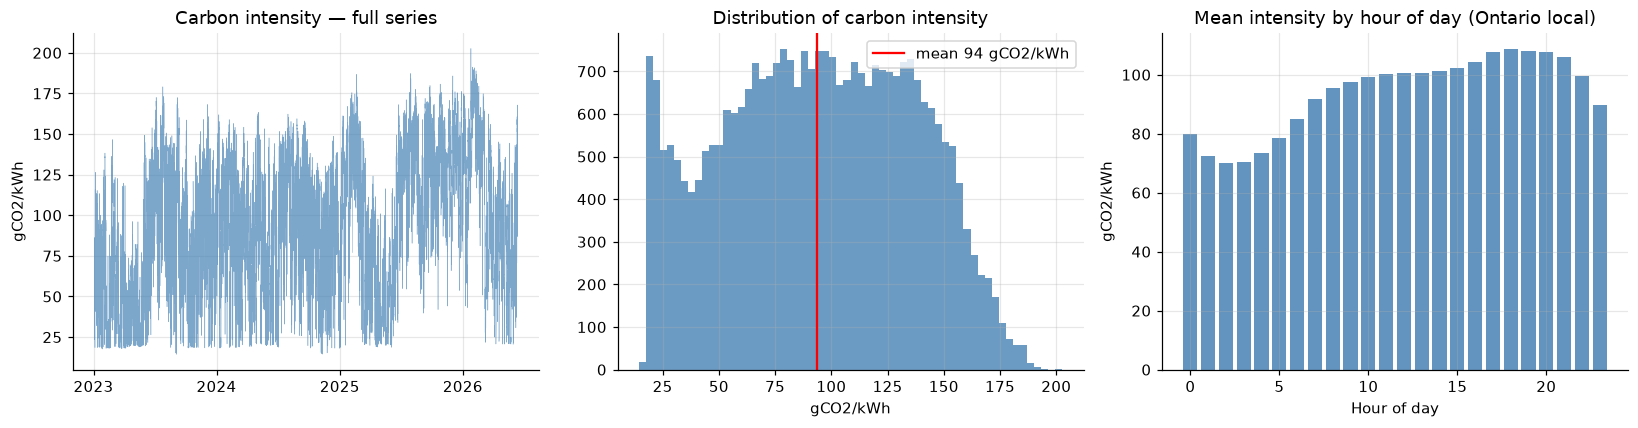

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full time series
axes[0].plot(df.index, df[TARGET], lw=0.3, alpha=0.7, color='steelblue')
axes[0].set_title('Carbon intensity — full series')
axes[0].set_ylabel('gCO2/kWh')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Distribution
axes[1].hist(df[TARGET], bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(df[TARGET].mean(), color='red', lw=1.5,
                label=f"mean {df[TARGET].mean():.0f} gCO2/kWh")
axes[1].set_title('Distribution of carbon intensity')
axes[1].set_xlabel('gCO2/kWh')
axes[1].legend()

# Mean by Ontario local hour
hourly_mean = df.groupby('hour_of_day')[TARGET].mean()
axes[2].bar(hourly_mean.index, hourly_mean.values, color='steelblue', alpha=0.85)
axes[2].set_title('Mean intensity by hour of day (Ontario local)')
axes[2].set_xlabel('Hour of day')
axes[2].set_ylabel('gCO2/kWh')

plt.tight_layout()
plt.show()

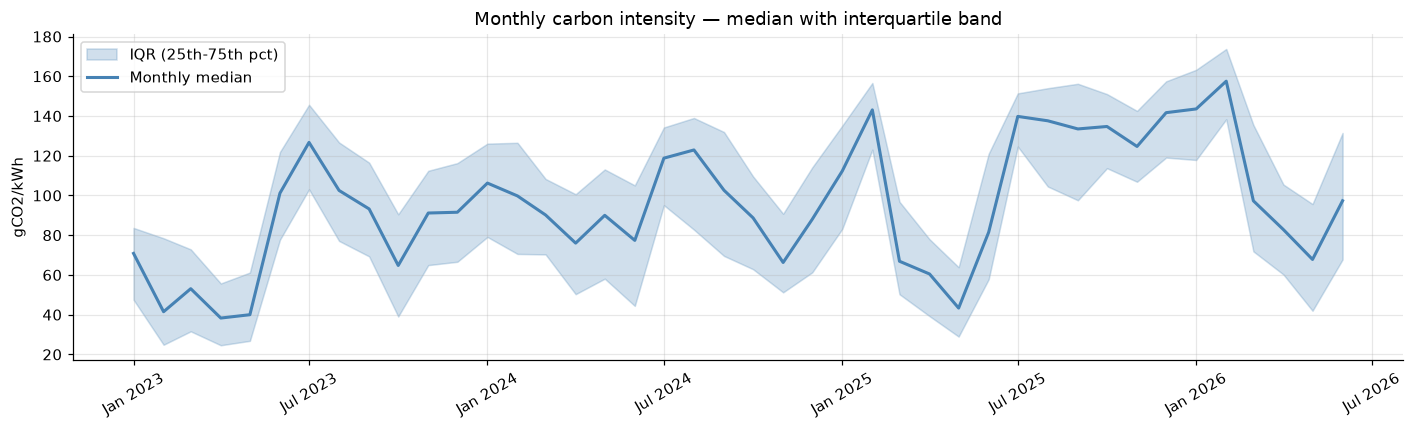

In [5]:
# Monthly median gives a cleaner seasonal signal than mean (less pulled by spikes)
monthly_median = df[TARGET].resample('MS').median()
monthly_q25    = df[TARGET].resample('MS').quantile(0.25)
monthly_q75    = df[TARGET].resample('MS').quantile(0.75)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly_median.index, monthly_q25, monthly_q75, alpha=0.25,
                color='steelblue', label='IQR (25th-75th pct)')
ax.plot(monthly_median.index, monthly_median.values, color='steelblue',
        lw=2, label='Monthly median')
ax.set_title('Monthly carbon intensity — median with interquartile band')
ax.set_ylabel('gCO2/kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Feature Correlations

Sample correlation captures *linear* relationships. Non-linear interactions won't show here — that's exactly why we use a tree model — but this gives intuition about which features carry signal before we open the black box.

What to expect:
- `pct_gas` → strong positive (more gas = higher CO2)
- `pct_nuclear`, `pct_hydro`, `pct_wind` → negative (zero-carbon fuels displace gas)
- `lag_24h` → moderate positive (autocorrelation is real but not overwhelming — the grid does change)
- Calendar features → weak linear correlation but strong non-linear signal

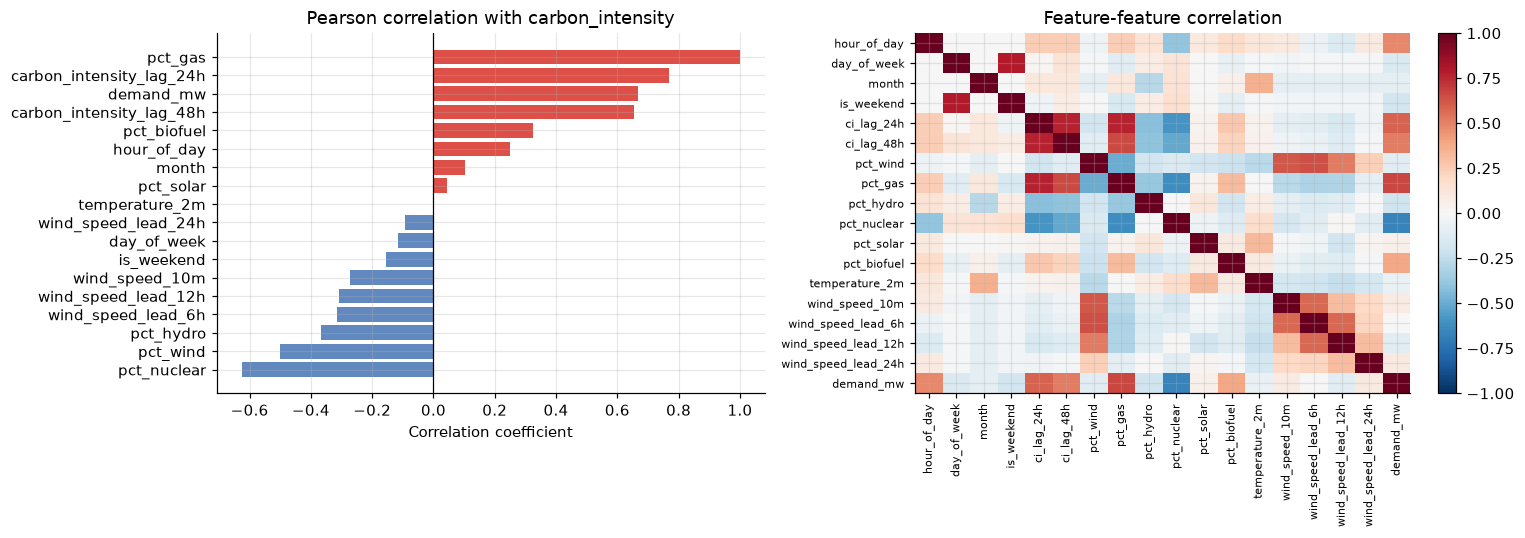

In [6]:
corr_with_target = df[FEATURE_COLS].corrwith(df[TARGET]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation with target
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_with_target.values]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Pearson correlation with carbon_intensity')
axes[0].set_xlabel('Correlation coefficient')

# Feature-feature correlation matrix (helps spot multicollinearity)
corr_matrix = df[FEATURE_COLS].corr()
short_names = [c.replace('carbon_intensity_', 'ci_') for c in FEATURE_COLS]
im = axes[1].imshow(corr_matrix.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
axes[1].set_xticks(range(len(FEATURE_COLS)))
axes[1].set_yticks(range(len(FEATURE_COLS)))
axes[1].set_xticklabels(short_names, rotation=90, fontsize=7)
axes[1].set_yticklabels(short_names, fontsize=7)
axes[1].set_title('Feature-feature correlation')
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 4. Single Horizon Model (h = 1)

Before running the full 24-horizon backtest, train one model to predict **one hour ahead** and inspect what LightGBM learned.

**Target construction:** for horizon h, the target at row i is `carbon_intensity[i + h]`. We create this by shifting the series backward by h steps with `.shift(-h)`. The last h rows have no valid target (NaN) and are excluded from training.

**Why temporal split?** A random split would let December 2024 data inform a January 2023 prediction — the model learns spurious relationships and looks much better than it will in production. We train on all data before 2025-01-01 and evaluate on everything after.

In [7]:
TRAIN_END = pd.Timestamp('2025-01-01', tz='UTC')

h = 1
target_h1   = df[TARGET].shift(-h)
baseline_h1 = df[TARGET].shift(24 - h)  # same hour yesterday relative to the target time

train_mask = (df.index < TRAIN_END) & target_h1.notna()
test_mask  = (df.index >= TRAIN_END) & target_h1.notna() & baseline_h1.notna()

X_train, y_train = df.loc[train_mask, FEATURE_COLS], target_h1[train_mask]
X_test,  y_test  = df.loc[test_mask,  FEATURE_COLS], target_h1[test_mask]

print(f'Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}')

model_h1 = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, random_state=42, verbose=-1
)
model_h1.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

preds_h1 = model_h1.predict(X_test)
mae_h1   = mean_absolute_error(y_test, preds_h1)
mae_base = mean_absolute_error(y_test, baseline_h1[test_mask])

print(f'\nh=1  Model MAE   : {mae_h1:.2f} gCO2/kWh')
print(f'h=1  Baseline MAE: {mae_base:.2f} gCO2/kWh  (same hour yesterday)')
print(f'h=1  Skill score : {1 - mae_h1/mae_base:.3f}  (positive = better than baseline)')

Train rows: 17,491  |  Test rows: 12,676

h=1  Model MAE   : 5.26 gCO2/kWh
h=1  Baseline MAE: 21.57 gCO2/kWh  (same hour yesterday)
h=1  Skill score : 0.756  (positive = better than baseline)


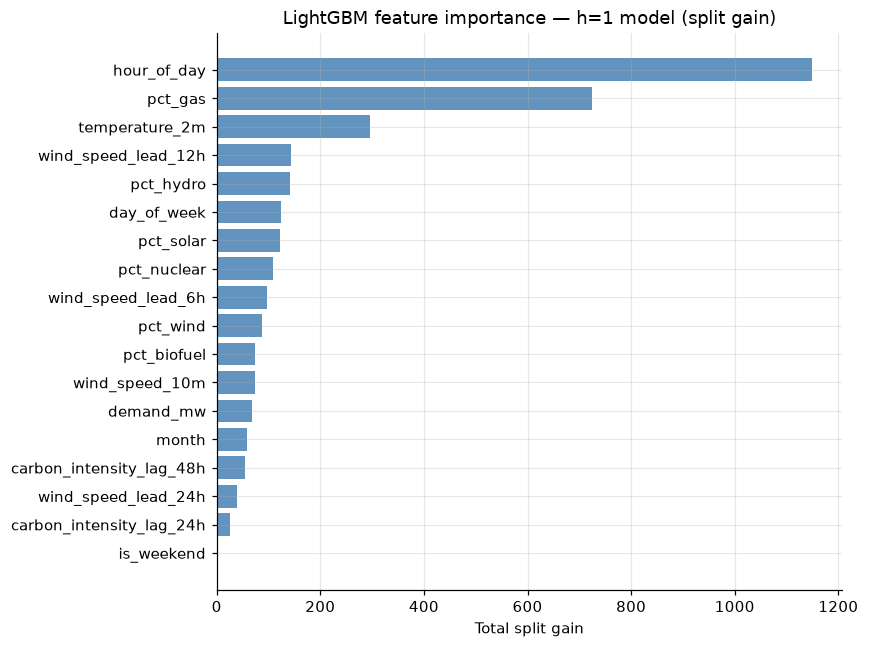

Top features:
hour_of_day            1150
pct_gas                 724
temperature_2m          295
wind_speed_lead_12h     144
pct_hydro               141
dtype: int32


In [8]:
importance = pd.Series(
    model_h1.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance.index, importance.values, color='steelblue', alpha=0.85)
ax.set_title('LightGBM feature importance — h=1 model (split gain)')
ax.set_xlabel('Total split gain')
plt.tight_layout()
plt.show()

print('Top features:')
print(importance.sort_values(ascending=False).head(5).round(0))

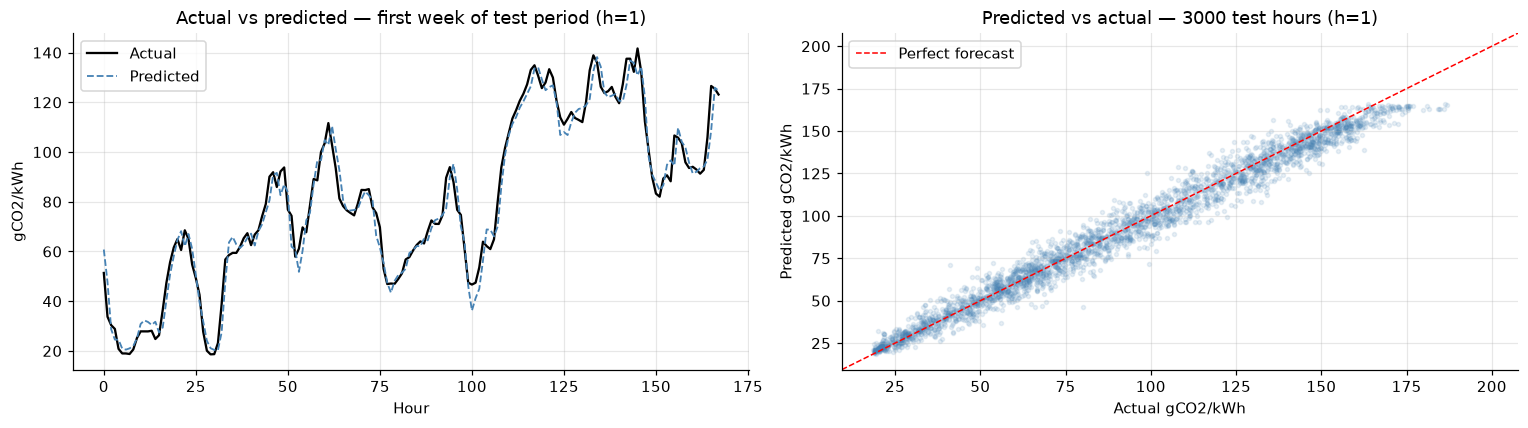

In [9]:
# One week of actuals vs predictions to see the qualitative fit
one_week = slice(0, 168)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(y_test.values[one_week],   label='Actual',    lw=1.5, color='black')
axes[0].plot(preds_h1[one_week],        label='Predicted', lw=1.2, color='steelblue', linestyle='--')
axes[0].set_title('Actual vs predicted — first week of test period (h=1)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('gCO2/kWh')
axes[0].legend()

# Scatter — points on the diagonal = perfect forecast
sample = slice(0, 3000)
axes[1].scatter(y_test.values[sample], preds_h1[sample],
                alpha=0.12, s=7, color='steelblue')
lims = [df[TARGET].min() - 5, df[TARGET].max() + 5]
axes[1].plot(lims, lims, 'r--', lw=1, label='Perfect forecast')
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_title('Predicted vs actual — 3000 test hours (h=1)')
axes[1].set_xlabel('Actual gCO2/kWh')
axes[1].set_ylabel('Predicted gCO2/kWh')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Walk-Forward Backtest (all 24 horizons)

Now the real evaluation. We train 24 models (one per horizon) and evaluate them across ~29 monthly folds.

**Protocol:**
- **Expanding window** — each fold trains on ALL data before the cutoff, so the model only improves as history accumulates
- **Test window** = the single month immediately after the cutoff
- No data from the future ever enters training at any fold
- Folds start at 2023-07 (6 months of warm-up) and run through 2025-11

**Baseline:** "same hour yesterday" — the simplest possible forecast. For a target at time T, the baseline prediction is `carbon_intensity[T - 24h]`. If our model can't beat this, it has no business being deployed.

**Expected runtime:** ~3-5 minutes (24 horizons × ~29 folds × fast LightGBM fits on a few thousand rows each).

In [10]:
HORIZONS = list(range(1, 25))
cutoffs  = pd.date_range('2023-07-01', '2025-11-01', freq='MS', tz='UTC')

all_results = {}

for h in HORIZONS:
    # For horizon h: target = carbon_intensity h steps ahead
    targets  = df[TARGET].shift(-h)
    # Baseline: same hour yesterday relative to the target time
    # target[i] is at time t+h; yesterday at that same hour is t+h-24 = shift(24-h)
    baseline = df[TARGET].shift(24 - h)

    actuals, preds, bases = [], [], []
    last_fold_data = None

    for i, cutoff in enumerate(cutoffs):
        test_end = cutoff + pd.DateOffset(months=1)

        train_mask = (df.index < cutoff) & targets.notna()
        test_mask  = (
            (df.index >= cutoff) & (df.index < test_end)
            & targets.notna() & baseline.notna()
        )

        if train_mask.sum() < 200 or test_mask.sum() == 0:
            continue

        model = lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=20, random_state=42, verbose=-1
        )
        model.fit(df.loc[train_mask, FEATURE_COLS], targets[train_mask])
        fold_preds = model.predict(df.loc[test_mask, FEATURE_COLS])

        actuals.extend(targets[test_mask].tolist())
        preds.extend(fold_preds.tolist())
        bases.extend(baseline[test_mask].tolist())

        if i == len(cutoffs) - 1:
            last_fold_data = {
                'actual':   targets[test_mask],
                'pred':     pd.Series(fold_preds, index=targets[test_mask].index),
                'baseline': baseline[test_mask],
            }

    mae_m = mean_absolute_error(actuals, preds)
    mae_b = mean_absolute_error(actuals, bases)
    all_results[h] = {
        'mae_model':    mae_m,
        'mae_baseline': mae_b,
        'skill':        1 - mae_m / mae_b,
        'last_fold':    last_fold_data,
    }
    print(f'h={h:2d}  MAE={mae_m:.2f}  baseline={mae_b:.2f}  skill={1-mae_m/mae_b:+.3f}')

print('\nDone.')

h= 1  MAE=4.98  baseline=21.76  skill=+0.771
h= 2  MAE=7.81  baseline=21.76  skill=+0.641
h= 3  MAE=9.80  baseline=21.76  skill=+0.550
h= 4  MAE=11.23  baseline=21.76  skill=+0.484
h= 5  MAE=12.41  baseline=21.76  skill=+0.430
h= 6  MAE=13.45  baseline=21.76  skill=+0.382
h= 7  MAE=14.36  baseline=21.76  skill=+0.340
h= 8  MAE=15.09  baseline=21.76  skill=+0.306
h= 9  MAE=15.58  baseline=21.76  skill=+0.284
h=10  MAE=15.96  baseline=21.76  skill=+0.266
h=11  MAE=16.32  baseline=21.77  skill=+0.250
h=12  MAE=16.74  baseline=21.77  skill=+0.231
h=13  MAE=17.02  baseline=21.77  skill=+0.218
h=14  MAE=17.39  baseline=21.77  skill=+0.202
h=15  MAE=17.74  baseline=21.78  skill=+0.185
h=16  MAE=17.97  baseline=21.78  skill=+0.175
h=17  MAE=17.85  baseline=21.78  skill=+0.180
h=18  MAE=17.95  baseline=21.78  skill=+0.176
h=19  MAE=17.80  baseline=21.78  skill=+0.183
h=20  MAE=17.64  baseline=21.79  skill=+0.190
h=21  MAE=17.47  baseline=21.79  skill=+0.198
h=22  MAE=17.45  baseline=21.79  skil

## 6. Evaluation

Three charts to tell the full story:

1. **MAE per horizon** — error should grow as we forecast further out. Information about the current state (fuel mix, temperature) decays with distance. If the curve is flat, the near-term features aren't helping as much as they should.
2. **Skill score** — `1 - MAE_model / MAE_baseline`. Positive = we beat the naive benchmark. This is the number you put on a resume or in a paper. Negative = the model is making things worse.
3. **Sample fold** — one month of actuals vs model vs baseline (h=1) to see the qualitative fit in the last test fold.

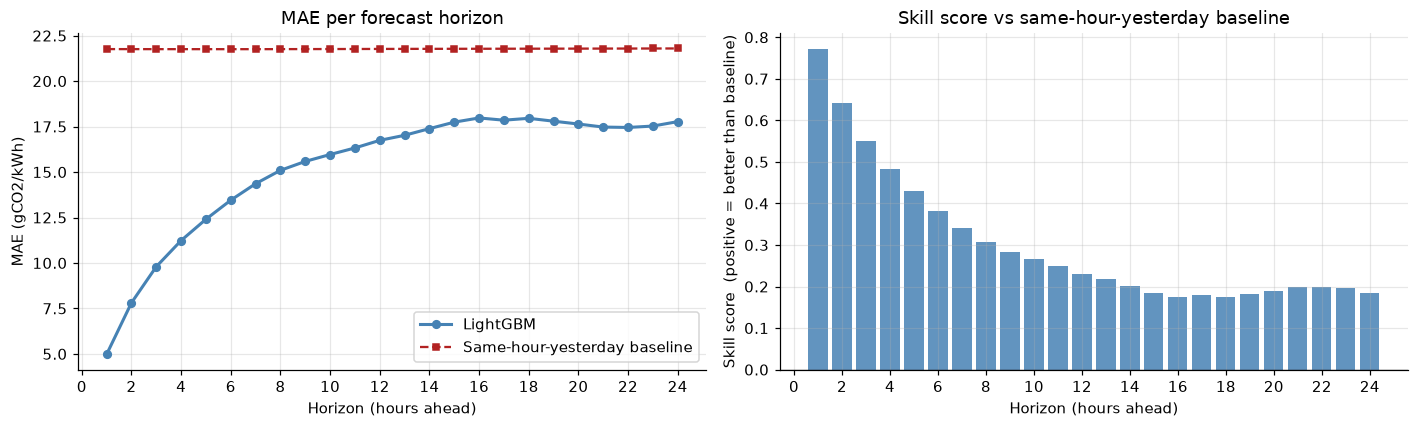

Best  horizon: h=1  MAE=4.98
Worst horizon: h=16  MAE=17.97
Mean skill score: 0.301


In [11]:
horizons     = HORIZONS
mae_model    = [all_results[h]['mae_model']    for h in horizons]
mae_baseline = [all_results[h]['mae_baseline'] for h in horizons]
skill_scores = [all_results[h]['skill']        for h in horizons]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(horizons, mae_model,    'o-',  label='LightGBM',
             color='steelblue', lw=2, markersize=5)
axes[0].plot(horizons, mae_baseline, 's--', label='Same-hour-yesterday baseline',
             color='firebrick', lw=1.5, markersize=4)
axes[0].set_title('MAE per forecast horizon')
axes[0].set_xlabel('Horizon (hours ahead)')
axes[0].set_ylabel('MAE (gCO2/kWh)')
axes[0].legend()
axes[0].set_xticks(range(0, 25, 2))

bar_colors = ['steelblue' if s > 0 else 'firebrick' for s in skill_scores]
axes[1].bar(horizons, skill_scores, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Skill score vs same-hour-yesterday baseline')
axes[1].set_xlabel('Horizon (hours ahead)')
axes[1].set_ylabel('Skill score  (positive = better than baseline)')
axes[1].set_xticks(range(0, 25, 2))

plt.tight_layout()
plt.show()

best_h  = min(horizons, key=lambda h: all_results[h]['mae_model'])
worst_h = max(horizons, key=lambda h: all_results[h]['mae_model'])
print(f'Best  horizon: h={best_h}  MAE={all_results[best_h]["mae_model"]:.2f}')
print(f'Worst horizon: h={worst_h}  MAE={all_results[worst_h]["mae_model"]:.2f}')
print(f'Mean skill score: {sum(skill_scores)/len(skill_scores):.3f}')

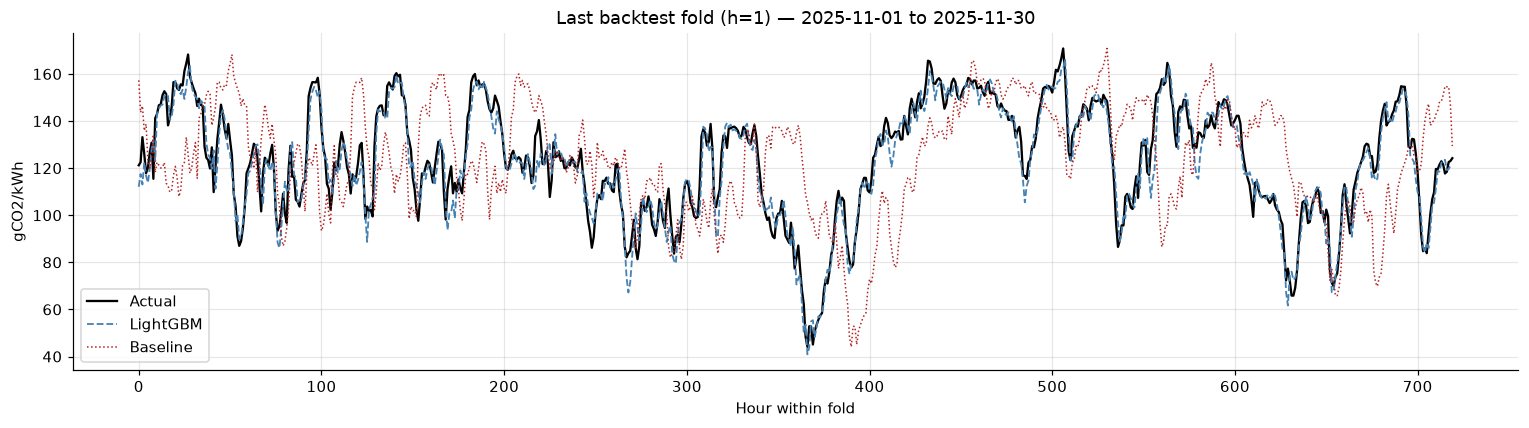

This fold: model MAE=4.79  baseline MAE=23.08  skill=+0.793


In [12]:
# Last backtest fold, h=1
lf = all_results[1]['last_fold']
start_date = lf['actual'].index[0].date()
end_date   = lf['actual'].index[-1].date()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(lf['actual'].values,   label='Actual',    lw=1.5, color='black')
ax.plot(lf['pred'].values,     label='LightGBM',  lw=1.2, color='steelblue',  linestyle='--')
ax.plot(lf['baseline'].values, label='Baseline',  lw=1.0, color='firebrick',  linestyle=':')
ax.set_title(f'Last backtest fold (h=1) — {start_date} to {end_date}')
ax.set_xlabel('Hour within fold')
ax.set_ylabel('gCO2/kWh')
ax.legend()
plt.tight_layout()
plt.show()

fold_mae  = mean_absolute_error(lf['actual'], lf['pred'])
fold_base = mean_absolute_error(lf['actual'], lf['baseline'])
print(f'This fold: model MAE={fold_mae:.2f}  baseline MAE={fold_base:.2f}  skill={1-fold_mae/fold_base:+.3f}')

## What comes next

This notebook validates the approach. The next step is `cleanwatt/model.py`, which will:

1. Run this same backtest and persist metrics to `models/eval_metrics.json`
2. Train **final production models** on the full available history (no held-out set — we already evaluated on walk-forward folds)
3. Save 24 `.pkl` artifacts to `models/model_h{n}.pkl`

Those artifacts are what `advisor.py` loads to produce the next-24h forecast and green/yellow/red window recommendation.